# MIE 402 — Pre-Lab 1: Prepare to Record Sound
**Fall 2026 · 20 points · Data analysis, no coding**

In Lab 1 you will connect a microphone to Moku:Go, record at different sample rates, export MAT files, and compare waveforms, spectra, and replayed sound. This notebook uses a **simulated microphone voltage** so that you can practice the same measurement decisions before entering the laboratory. It is not measured laboratory data.

## What you must submit

Submit **one Word or PDF file** on Canvas before your own laboratory section begins. Your file must contain:

1. Your name, laboratory section, GTA, and submission date.
2. The calculations and written response for **Task 1**.
3. The completed prediction table and explanation for **Task 2**, prepared before you run the sampling cells.
4. All five time-domain plots and all five FFT plots produced by the notebook.
5. The completed results table and answers for **Task 3**.
6. Your prediction, comparison figure, and written explanation for **Task 4**.
7. Both duration/FFT figures and both answers for **Task 5**.
8. Your practical Lab 1 acquisition plan for **Task 6**.

You may type directly in the notebook and export it, or copy the requested results and figures into a clearly organized Word document. **Do not submit only screenshots or a notebook with blank response cells.** Every figure must have readable axes, and every numerical answer must include units.

## How to complete the notebook

- Save a personal copy in Google Drive.
- Work from top to bottom. Complete every **Prediction** or calculation before running the cell immediately below it.
- Run every code cell in order. The code is complete; do not write or repair Python code.
- Use the printed values and plots as evidence in your responses. Explain what the result means physically.
- Keep all generated figures visible in the submitted file.
- Export the completed work to Word or PDF and verify that every page and figure is readable.

Pre-labs normally appear on Canvas on the Monday before the laboratory. Late pre-labs are not accepted. You may discuss the general approach, but the submitted calculations and explanations must be your own work.

[Read the lecture and laboratory walkthrough](https://ehsan-roohi.github.io/MIE402-Lab/lecture02.html)


## What each quantity means

A microphone converts changing sound pressure into changing voltage. We model one clean tone by

$$x(t)=A_1\sin(2\pi f_1t+\phi_1),\quad A_1=0.80\;\mathrm V,\ f_1=320\;\mathrm{Hz},\ \phi_1=30^\circ.$$

- **A1**: voltage from zero to a crest, not peak-to-peak voltage.
- **f1**: physical cycles per second; its period is $T_{signal}=1/f_1$.
- **phi1_deg**: starting phase in degrees. Positive phase advances this sine wave. The code converts degrees to radians.
- **fs**: samples stored per second, chosen on the recorder. It does not change the original tone.
- **N**: number of samples. Sample spacing $\Delta t=1/f_s$; FFT record duration $T_{record}=N/f_s$.

The **320 Hz value is a new teaching example**, not the frequency of every laboratory fork. Read the label on your actual fork. We use the same laboratory rate multipliers: **100f, 10f, 3f, 1.4f, 1f**, with $f=f_1$ for this pure tone.

## Theory you will use

**Mean and RMS:** $\mu=N^{-1}\sum x[n]$ and $x_{RMS}=\sqrt{N^{-1}\sum x[n]^2}$. A zero-offset sinusoid over complete cycles has mean zero and RMS $A/\sqrt2$. A transient's RMS depends on the chosen interval.

**Sampling:** the Nyquist boundary is $f_N=f_s/2$. For an ideally band-limited baseband signal, choose $f_s>2f_{max}$, with practical margin and filtering. A component above this boundary can appear at $f_{alias}=|f-kf_s|$, choosing integer $k$ to put the result between 0 and $f_s/2$. Exactly at the boundary, phase can make samples misleading.

**Spectrum:** the FFT efficiently computes the DFT of the stored record. Frequency-bin spacing is $\Delta f=f_s/N=1/T_{record}$. A longer record makes bins finer; raising $f_s$ at fixed duration raises the Nyquist boundary without changing bin spacing. A Hann window reduces distant leakage but widens peaks. It cannot fix aliasing.

**DC:** a constant sequence appears at 0 Hz. Do not automatically discard that bin: it is essential in the lowest-rate case.

**Replay:** use the recorded sample rate, or properly resample for the audio device. Using the sample count as the playback rate is valid only for an exactly one-second record.

## Task 1 — Prepare the acquisition (3 points)

Before running the reference cell, calculate the signal period in milliseconds, theoretical mean, and theoretical RMS over one second. State what quantity the microphone/DAQ records and why a voltage amplitude is not yet a calibrated sound pressure.

**Response:**

T = 1 second / 320 hz = 3.125 ms

𝜇 = 0 (Recording time = 1 s, f1 = 320 hz, 320 * 3.125 = 1000 ms = 1 s)

Xrms = A1 / sqrt(2) = 0.8 / sqrt(2) ~= 0.566 V

The microphone responds to changes in sound wave pressure and its transducer converts this motion into a proportional voltage. The DAQ samples this voltage straight from the mic.

Voltage amplitude measurements depend on the specific microphone and how it's set up. Two different microphones will report different voltage amplitudes for the same sound wave pressure. The sensitivity factor of the specific microphone must first be divided out before the actual amplitude can be calculated.

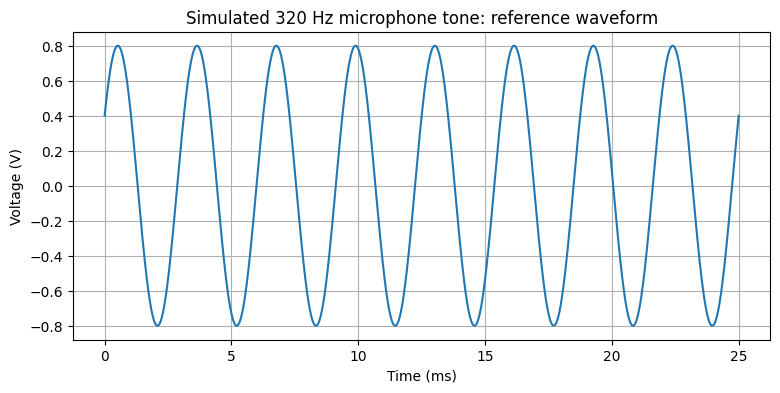

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 10, "figure.figsize": (9, 4)})
A1, f1, phi1_deg = 0.80, 320.0, 30.0
duration = 1.0
multipliers = [100, 10, 3, 1.4, 1]
sample_rates = [m*f1 for m in multipliers]
def signal(t):
    return A1*np.sin(2*np.pi*f1*t + np.deg2rad(phi1_deg))
def stats(x):
    return float(np.mean(x)), float(np.sqrt(np.mean(x*x)))
def spectrum(x, fs, taper=False):
    n = len(x)
    w = np.hanning(n) if taper else np.ones(n)
    mag = np.abs(np.fft.rfft(x*w))/np.sum(w)
    if n % 2 == 0:
        mag[1:-1] *= 2  # DC and the even-length Nyquist bin stay undoubled
    else:
        mag[1:] *= 2   # Odd N has no Nyquist bin
    return np.fft.rfftfreq(n, 1/fs), mag
# Prepared reference; no coding is required.
t_dense = np.linspace(0, 0.025, 4000)
plt.plot(1000*t_dense, signal(t_dense))
plt.xlabel("Time (ms)"); plt.ylabel("Voltage (V)")
plt.title("Simulated 320 Hz microphone tone: reference waveform")
plt.grid(); plt.show()


## Task 2 — Predict BEFORE recording (4 points)

Complete this table **before running the next cell**. Calculate the sample interval and Nyquist boundary. Predict the represented frequency; include 0 Hz if appropriate. Explain the last two cases, using the starting phase to predict the values when $f_s=f_1$.

| Rate multiplier | fs (samples/s) | Δt (ms) | Nyquist (Hz) | Samples per cycle | Predicted represented frequency (Hz) |
|---|---:|---:|---:|---:|---:|
| 100f | 32000 | 0.03125 | 16000 | 100 | 320 |
| 10f | 3200 | 0.3125 | 1600 | 10 | 320 |
| 3f | 960 | 1.04167 | 480 | 3 | 320 |
| 1.4f | 448 | 2.23214 | 224 | 1.4 | 12 |
| 1f | 320 | 3.125 | 160 | 1 | |

**Calculations and explanation:**

1s/32000 hz = 0.03125 ms

1s/3200 hz = 0.3125 ms

1s/960 hz = 1.04167 ms

1s/448 hz = 2.23214

fN = fs/2

32000/2 = 16000 hz

3200/2 = 1600 hz

960/2 = 480 hz

448/2 = 224 hz

320/2 = 160 hz

f_alias = |f-kf_s|

100f: fN = 16000 > 320 hz, fa = 320 - 0 = 320hz
1600 > 320 , 480 > 320, fa(10f) = fa(3f) = fa(100f) = 320hz

1.4f: fN = 224 < 320hz, fa = |320 - (1)448| = 128 hz < 224

1f: fN = 160 < 320hz fa = |320 - (1)320| = 0 hz < 160

1.4f: Because fN 224 Hz < f1 the sampling theorem is violated. The tone folds back into the observable band |320 - 448| = 128 Hz, and 128 Hz < 224, so the FFT will show energy at 128 Hz even though no 128 Hz component exists in the real signal.

1f: The phase argument at each sample is 2πn + φ, and since 2πn is a full number of turns, every sample lands at exactly the same point in the cycle, so x[n] 0.80 x sin(30deg) = 0.40 V for every sample. This repeating signal is aliased to 0 hz.

multiplier | fs (samples/s) | N | mean (V) | RMS (V)
   100f |    32000 | 32000 | -0.000000 | 0.565685
    10f |     3200 |  3200 |  0.000000 | 0.565685
     3f |      960 |   960 | -0.000000 | 0.565685
   1.4f |      448 |   448 |  0.000000 | 0.565685
     1f |      320 |   320 |  0.400000 | 0.400000


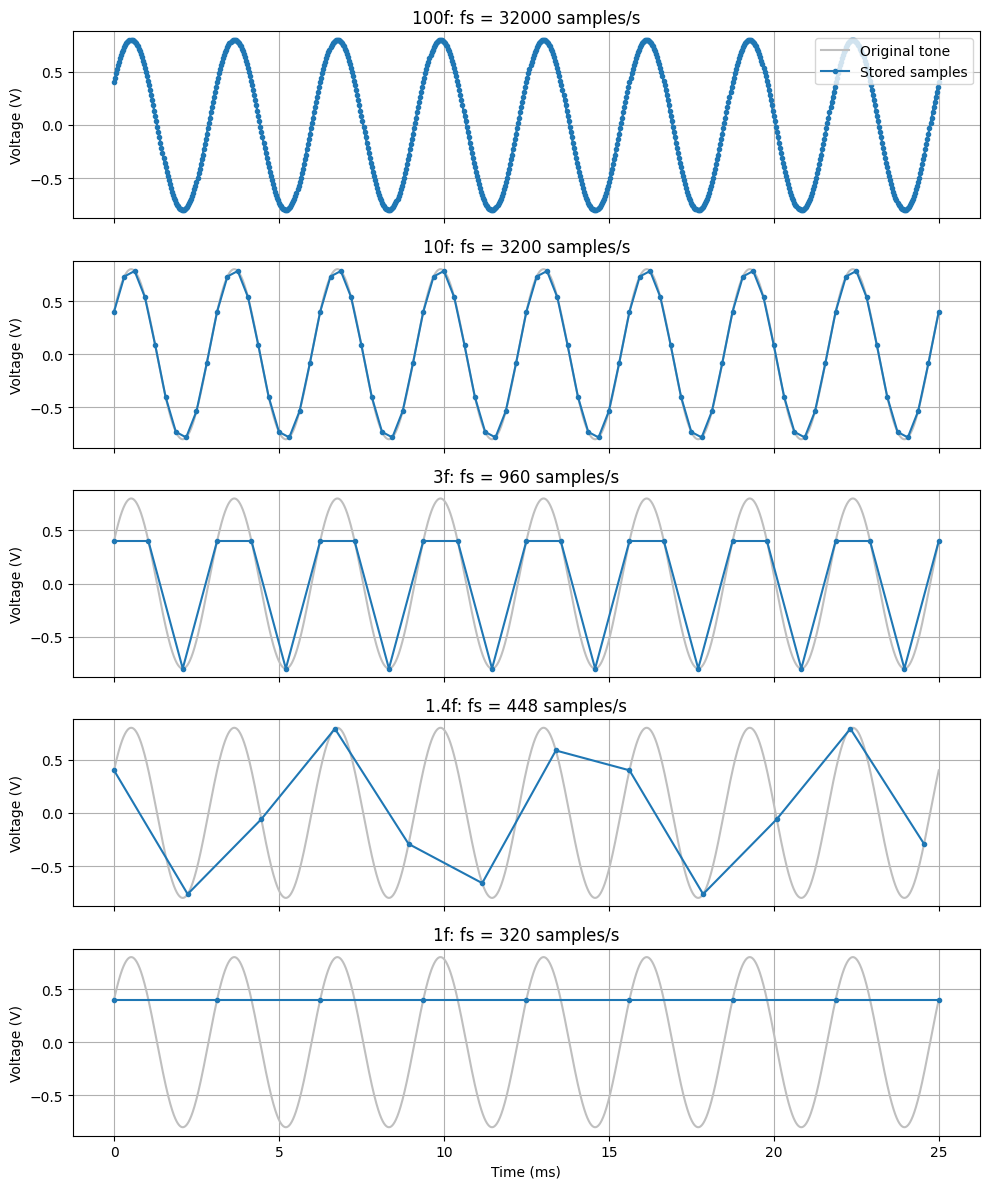

In [2]:
records = {}
fig, axes = plt.subplots(5, 1, figsize=(10, 12), sharex=True, sharey=True)
print("multiplier | fs (samples/s) | N | mean (V) | RMS (V)")
for ax, m, fs in zip(axes, multipliers, sample_rates):
    count = int(round(duration*fs))
    t = np.arange(count)/fs
    x = signal(t)
    records[fs] = (t, x)
    mean, rms = stats(x)
    print(f"{m:6g}f | {fs:8g} | {count:5d} | {mean: .6f} | {rms:.6f}")
    keep = t <= 0.025
    ax.plot(1000*t_dense, signal(t_dense), color="0.75", label="Original tone")
    ax.plot(1000*t[keep], x[keep], "o-", ms=3, label="Stored samples")
    ax.set_title(f"{m:g}f: fs = {fs:g} samples/s")
    ax.set_ylabel("Voltage (V)"); ax.grid()
axes[0].legend(loc="upper right")
axes[-1].set_xlabel("Time (ms)")
plt.tight_layout(); plt.show()


fs | strongest bin including DC | one-sided amplitude
32000 | 320.000 Hz | 0.800000 V
3200 | 320.000 Hz | 0.800000 V
960 | 320.000 Hz | 0.800000 V
448 | 128.000 Hz | 0.800000 V
320 | 0.000 Hz | 0.400000 V


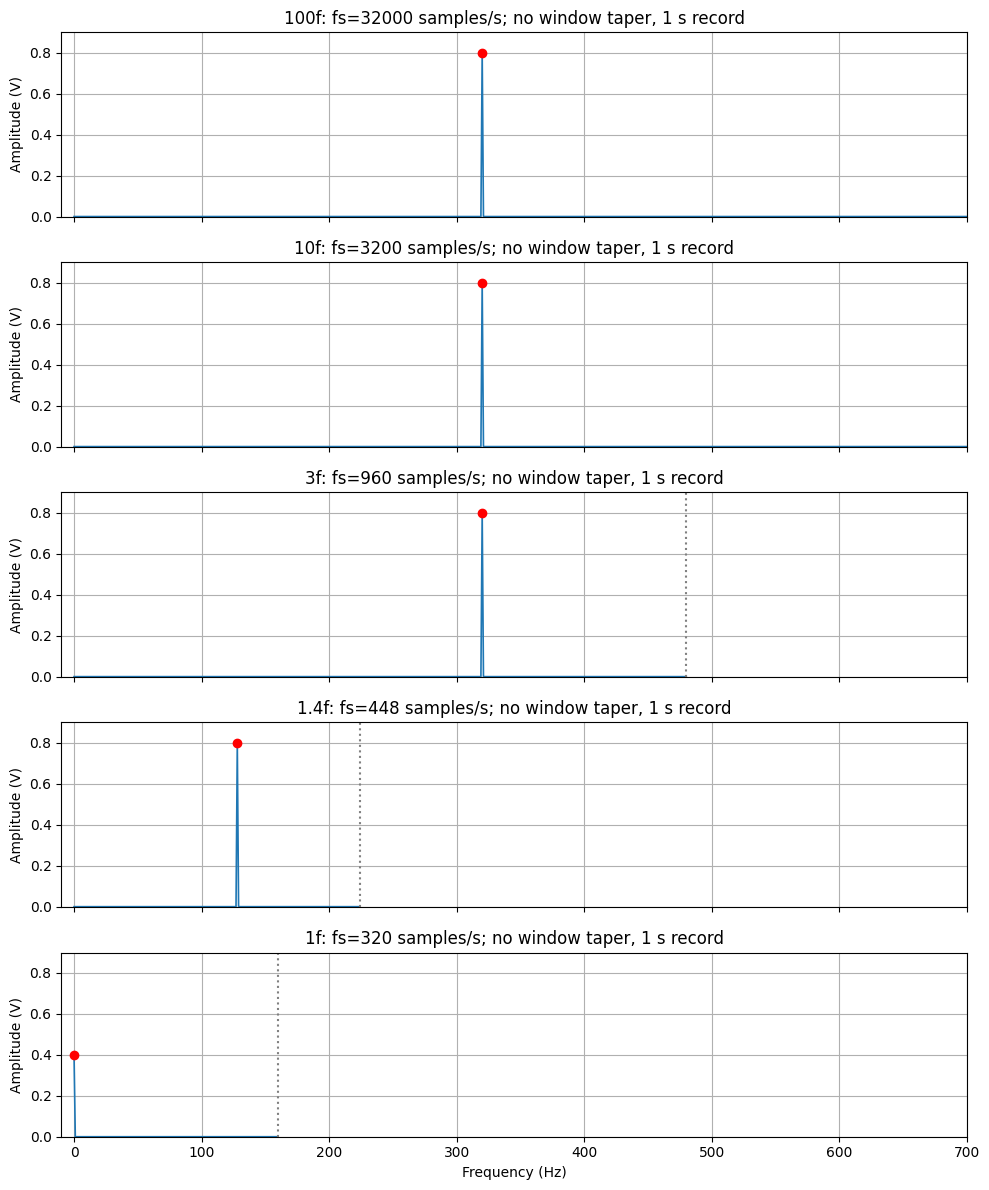

In [3]:
fig, axes = plt.subplots(5, 1, figsize=(10, 12), sharex=True, sharey=True)
print("fs | strongest bin including DC | one-sided amplitude")
for ax, m, fs in zip(axes, multipliers, sample_rates):
    _, x = records[fs]
    frequency, magnitude = spectrum(x, fs)
    use = frequency <= 700
    ax.plot(frequency[use], magnitude[use], lw=1.2)
    peak = int(np.argmax(magnitude))
    ax.plot(frequency[peak], magnitude[peak], "ro")
    print(f"{fs:g} | {frequency[peak]:.3f} Hz | {magnitude[peak]:.6f} V")
    ax.axvline(fs/2, color="0.5", ls=":", label="Nyquist boundary")
    ax.set_xlim(-10, 700); ax.set_ylim(0, 0.9)
    ax.set_title(f"{m:g}f: fs={fs:g} samples/s; no window taper, 1 s record")
    ax.set_ylabel("Amplitude (V)"); ax.grid()
axes[-1].set_xlabel("Frequency (Hz)")
plt.tight_layout(); plt.show()


## Task 3 — Validate the acquired signal (5 points)

Use numerical output and figures as evidence. Keep voltage statistics separate from frequency comparisons.

| fs (samples/s) | Observed mean (V) | Observed RMS (V) | RMS error vs theoretical (%) | Strongest FFT bin including DC (Hz) |
|---:|---:|---:|---:|---:|
| 32000 | | | | |
| 3200 | | | | |
| 960 | | | | |
| 448 | | | | |
| 320 | | | | |

1. Calculate RMS error as $100|RMS_{sample}-RMS_{theory}|/RMS_{theory}$.
2. Compare each FFT result with your prediction. Explain why the source did not physically change when the recorded frequency changed.
3. Identify a case where RMS alone would falsely suggest a successful measurement. Explain why a constant low-rate trace is not proof the microphone heard silence.
4. Which recording would you show the GTA to validate the fork measurement, and what two figures would you show?

**Response:**



## Task 4 — Real sounds are not always pure tones (3 points)

A whistle may have harmonics above its fundamental. A snap is a short event with broad frequency content and no single fundamental. The following prepared comparison adds a **0.20 V second harmonic at 640 Hz** to the 320 Hz tone. Compare a high-rate record with 3f sampling.

Before running: is 3f adequate for the **highest frequency** now present? Predict where 640 Hz can appear at fs = 960 samples/s.

**Prediction:**



In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
for ax, fs in zip(axes, [32000.0, 960.0]):
    t = np.arange(int(fs))/fs
    x = signal(t) + 0.20*np.sin(2*np.pi*640*t)
    freq, amp = spectrum(x, fs)
    ax.plot(freq, amp)
    ax.set_xlim(0, 800); ax.set_ylim(0, 1.1)
    ax.set_title(f"320 Hz tone + 640 Hz harmonic; fs={fs:g} samples/s")
    ax.set_ylabel("Amplitude (V)"); ax.grid()
axes[-1].set_xlabel("Frequency (Hz)")
plt.tight_layout(); plt.show()


**Response:** Explain why “three samples per fundamental cycle” does not guarantee an accurate recording of this sound. Explain why a snap needs a stated frequency-band/reference choice, rather than pretending it is a pure tone. How would you use a high-rate pilot record and the GTA’s guidance before choosing its rate matrix?



## Task 5 — Duration and playback (3 points)

The lab requires recordings of at least one second. The 0.25 s record below is only a teaching comparison. Both cases use the same 10f sample rate and a Hann window.


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7))
for ax, requested in zip(axes, [0.25, 2.0]):
    fs = 3200.0
    n = int(round(requested*fs))
    t = np.arange(n)/fs
    freq, amp = spectrum(signal(t), fs, taper=True)
    keep = (freq >= 300) & (freq <= 340)
    ax.stem(freq[keep], amp[keep], basefmt=" ")
    ax.set_title(f"N={n}; actual duration={n/fs:g} s; FFT-bin spacing={fs/n:g} Hz")
    ax.set_xlabel("Frequency (Hz)"); ax.set_ylabel("Amplitude (V)"); ax.grid()
plt.tight_layout(); plt.show()


**Response:**

1. State both bin spacings and both Nyquist boundaries. Why does a longer record improve the frequency grid but not repair aliasing? A finer grid alone is not a guarantee of resolving every pair of close tones.
2. A file has **6400 samples recorded at 3200 samples/s**. What is its duration? If someone incorrectly uses 6400 as the playback rate, what are the playback duration and apparent frequency of its 320 Hz tone? Explain why this is a playback error rather than an acquisition alias.



## Task 6 — Your Lab 1 plan (2 points)

Write a short, usable plan covering:
- Connect the microphone to an input and confirm the correct Moku serial number/channel.
- Choose a frequency reference for each of three sounds; collect the five required rate cases for at least one second each.
- Record rate, duration, mode, source identity, filename, and relevant distance/gain settings.
- Export MAT data, inspect time spacing, plot waveform and spectrum, and replay at the correct rate when supported.
- Show one valid fork dataset and spectrum to the GTA, and back up the raw data.

Include one action you would take if the high-rate trace is flat or clipped. Describe actions and analysis; no code is requested.

**Response:**

